In [1]:
from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_10.pth"))
model.eval()

print(model)

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_16772\3302928597.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_10.pth"))


ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

In [2]:


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


torch.Size([1, 8, 17, 17])


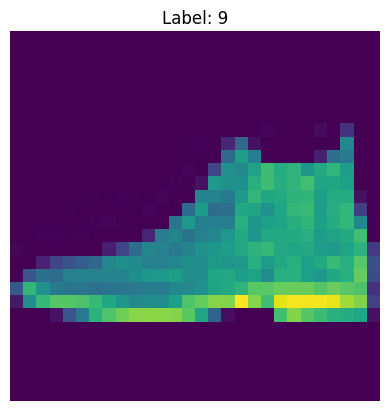

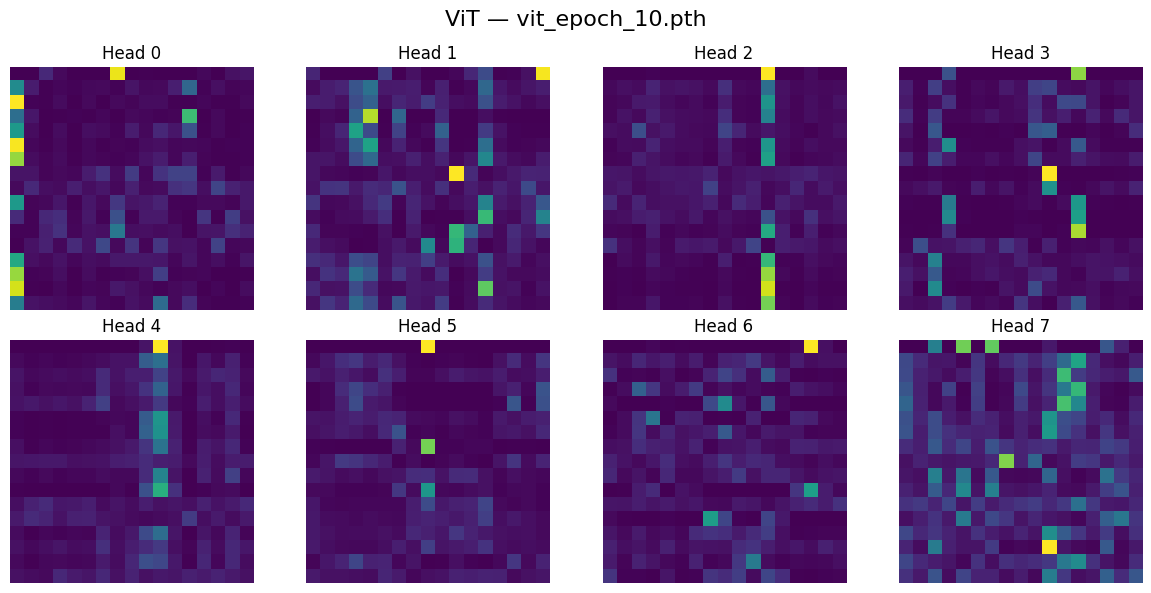

In [3]:


import matplotlib.pyplot as plt



plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_10.pth", fontsize=16)

for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")

Head 0:
tensor([0.9017, 1.9399, 1.0090, 1.3613, 1.8871, 1.0534, 1.4338, 2.4232, 2.5999,
        2.0641, 2.3703, 2.3149, 2.4397, 2.0712, 1.2740, 1.1633, 2.0007])
 Entropy = 1.7828
Head 1:
tensor([1.4663, 2.3936, 2.5430, 1.3999, 1.9732, 1.9365, 2.3429, 1.7599, 2.6573,
        2.4080, 1.8944, 2.0355, 1.9345, 2.6043, 2.4110, 2.0918, 2.4446])
 Entropy = 2.1351
Head 2:
tensor([0.2068, 2.3249, 1.9845, 2.1310, 2.4393, 1.9530, 1.8218, 2.7856, 2.6646,
        2.6997, 2.5427, 1.6566, 2.5651, 1.5157, 0.9820, 0.5950, 1.1244])
 Entropy = 1.8819
Head 3:
tensor([0.5491, 2.4150, 2.3189, 2.5269, 1.7047, 1.6947, 2.5101, 0.4316, 2.0339,
        1.2811, 0.9336, 0.7542, 2.4660, 2.2682, 2.4886, 1.8753, 2.3411])
 Entropy = 1.7996
Head 4:
tensor([0.4894, 2.0879, 2.6368, 2.3832, 2.6111, 1.6227, 1.6334, 2.2284, 2.7702,
        2.0381, 1.3273, 2.7562, 2.6783, 2.1689, 2.6318, 2.3846, 2.7586])
 Entropy = 2.1886
Head 5:
tensor([0.0031, 2.3908, 2.7049, 2.0079, 1.8215, 2.6924, 2.4476, 0.9400, 2.3925,
        2.6276, 1

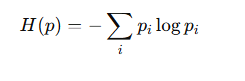

ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_16772\3644072237.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_20.pth"))


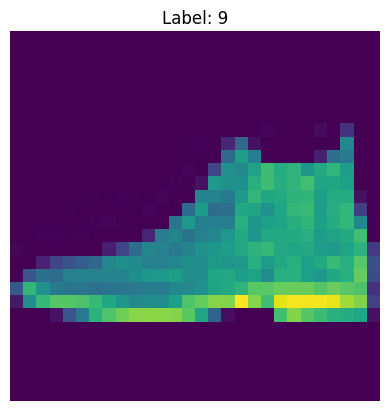

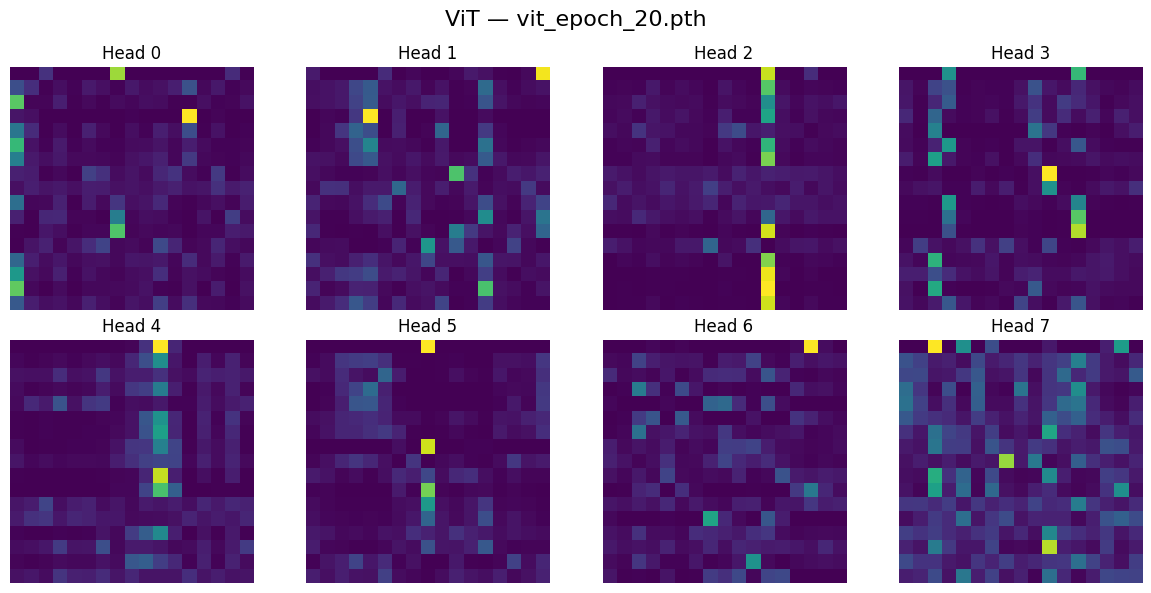

Head 0:
tensor([0.7909, 2.3661, 1.4932, 0.5654, 2.0088, 1.6918, 2.1978, 2.4213, 2.7725,
        2.2743, 2.0440, 1.5184, 2.4125, 2.4573, 2.0106, 1.4288, 2.4123])
 Entropy = 1.9333
Head 1:
tensor([1.0935, 2.2761, 2.3787, 0.9867, 1.9121, 1.8712, 2.4045, 1.8325, 2.4788,
        2.4351, 1.8604, 2.0097, 1.8787, 2.5569, 2.4708, 1.8845, 2.3373])
 Entropy = 2.0393
Head 2:
tensor([0.4429, 1.3605, 2.0778, 1.8238, 2.4529, 1.6182, 1.1777, 2.7892, 2.6832,
        2.7426, 2.4306, 0.6519, 2.3866, 1.1015, 0.4488, 0.3269, 0.6578])
 Entropy = 1.5984
Head 3:
tensor([0.7065, 2.2826, 2.3462, 2.3157, 1.5603, 1.7855, 1.9899, 0.7681, 2.0879,
        1.3766, 0.9589, 0.7685, 2.4357, 1.8739, 2.6175, 1.6367, 2.2280])
 Entropy = 1.7493
Head 4:
tensor([0.7370, 2.0311, 2.7133, 2.1994, 2.4999, 1.8180, 1.7844, 2.0484, 2.4718,
        1.1146, 1.1566, 2.7037, 2.7261, 1.8703, 2.5698, 2.2444, 2.7417])
 Entropy = 2.0841
Head 5:
tensor([0.0066, 2.1695, 2.2226, 1.7950, 1.8496, 2.5926, 2.4045, 0.3909, 2.4048,
        2.4517, 0

In [5]:

from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_20.pth"))
model.eval()

print(model)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


# %%


import matplotlib.pyplot as plt


plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_20.pth", fontsize=16)


for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %%
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")






ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_16772\443785888.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_30.pth"))


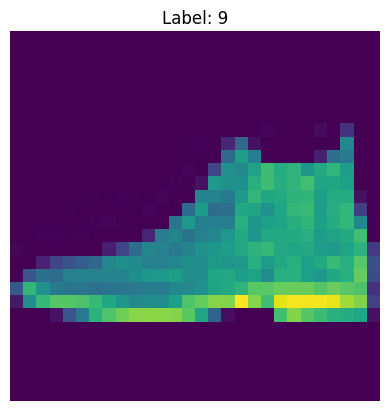

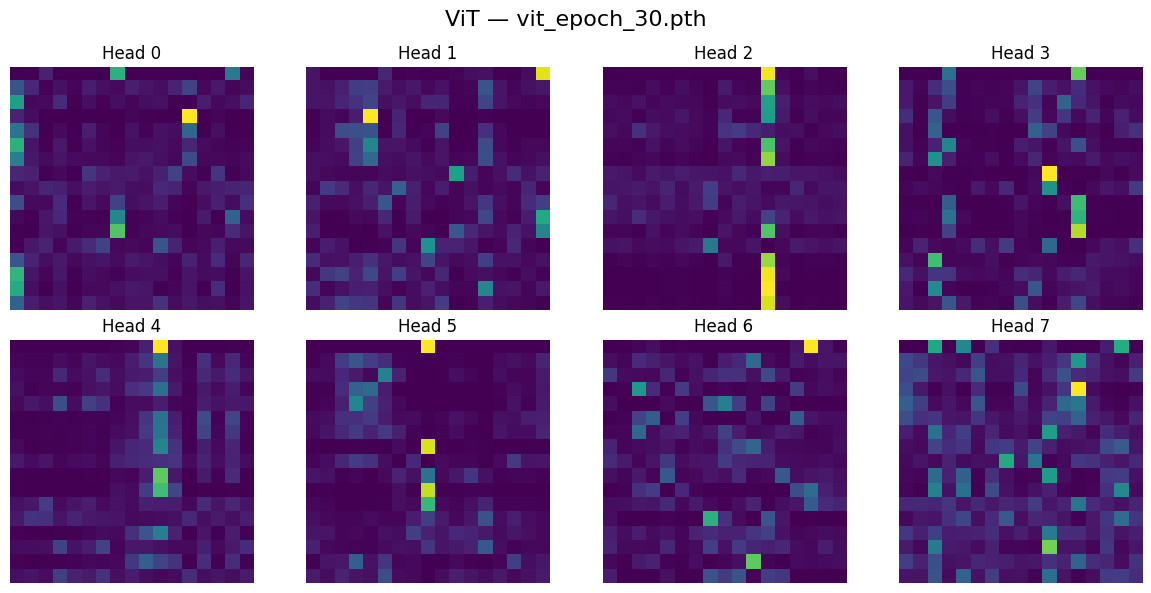

Head 0:
tensor([1.0146, 2.4693, 1.9277, 0.6313, 1.8893, 1.8059, 2.1883, 2.4633, 2.7432,
        2.4225, 1.8112, 1.5358, 2.4138, 2.5499, 1.8213, 1.7995, 2.5141])
 Entropy = 2.0001
Head 1:
tensor([1.0034, 2.4939, 2.5306, 0.8335, 2.0067, 2.0375, 2.3078, 2.0865, 2.4257,
        2.4417, 1.7692, 1.9785, 2.0285, 2.6196, 2.3928, 2.2719, 2.4081])
 Entropy = 2.0962
Head 2:
tensor([0.3165, 1.2476, 1.8918, 1.8206, 2.5236, 1.4244, 1.0285, 2.7882, 2.6626,
        2.6931, 2.6227, 1.3916, 2.3104, 0.9441, 0.4022, 0.3100, 0.5781])
 Entropy = 1.5856
Head 3:
tensor([0.6700, 2.3873, 2.2584, 2.3147, 1.8306, 1.9373, 2.0630, 0.6577, 1.9439,
        1.1962, 1.1413, 0.7789, 2.2495, 1.6891, 2.5969, 1.8708, 2.2228])
 Entropy = 1.7534
Head 4:
tensor([0.6014, 2.2335, 2.6077, 2.2645, 2.4890, 1.8939, 1.9954, 2.0234, 2.6280,
        1.3302, 1.2106, 2.6893, 2.7068, 1.8969, 2.5815, 2.0875, 2.6587])
 Entropy = 2.1117
Head 5:
tensor([2.1577e-03, 2.0471e+00, 2.0018e+00, 1.6612e+00, 1.6727e+00, 2.5157e+00,
        2.4117e+0

In [6]:

from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_30.pth"))
model.eval()

print(model)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


# %%


import matplotlib.pyplot as plt


plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_30.pth", fontsize=16)


for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %%
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")






ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_16772\2147895923.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_40.pth"))


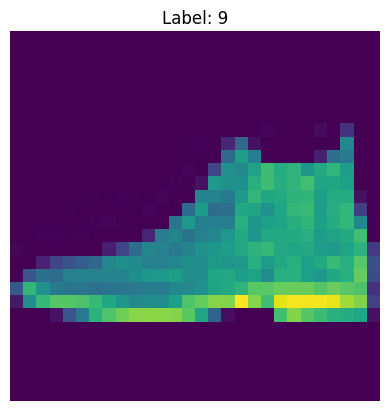

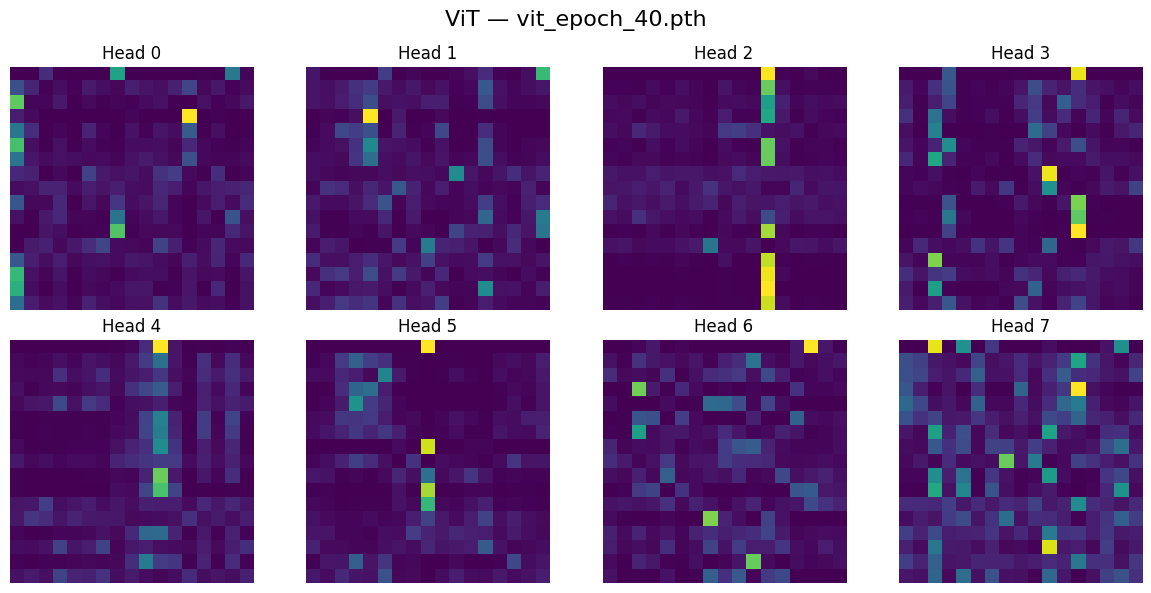

Head 0:
tensor([1.1014, 2.4414, 1.4514, 0.5281, 1.8889, 1.5610, 2.2146, 2.3838, 2.7188,
        2.3841, 2.0300, 1.4668, 2.4584, 2.5453, 1.7266, 1.7108, 2.3735])
 Entropy = 1.9403
Head 1:
tensor([1.4400, 2.4941, 2.4370, 0.6744, 2.0305, 1.9817, 2.2483, 2.1945, 2.4549,
        2.4413, 1.9062, 2.1523, 2.1144, 2.6183, 2.3881, 2.1616, 2.4570])
 Entropy = 2.1291
Head 2:
tensor([0.1961, 1.1860, 1.8681, 1.7066, 2.4956, 1.2036, 1.2194, 2.7843, 2.6999,
        2.7780, 2.5677, 0.8676, 2.3137, 0.6677, 0.3363, 0.2093, 0.5882])
 Entropy = 1.5111
Head 3:
tensor([0.5705, 2.3875, 2.2815, 2.2413, 1.7270, 2.0082, 1.9786, 1.0494, 2.0067,
        1.2091, 1.0972, 0.7216, 2.3316, 1.5693, 2.5884, 1.7759, 2.3204])
 Entropy = 1.7567
Head 4:
tensor([0.6812, 2.2754, 2.6162, 2.3632, 2.5602, 1.8390, 1.9068, 1.9937, 2.5485,
        1.3544, 1.1942, 2.7189, 2.7136, 2.0461, 2.5902, 2.0420, 2.6487])
 Entropy = 2.1231
Head 5:
tensor([0.0046, 1.9735, 1.9835, 1.6200, 1.5770, 2.4534, 2.4650, 0.3963, 2.4087,
        2.1419, 0

In [7]:

from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_40.pth"))
model.eval()

print(model)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


# %%


import matplotlib.pyplot as plt

plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_40.pth", fontsize=16)


for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %%
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")






ViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(7, 7))
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (to_qkv): Linear(in_features=128, out_features=384, bias=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_af

C:\Users\user\AppData\Local\Temp\ipykernel_16772\3482962859.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vit_epoch_50.pth"))


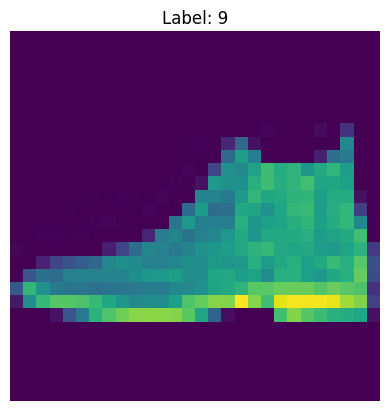

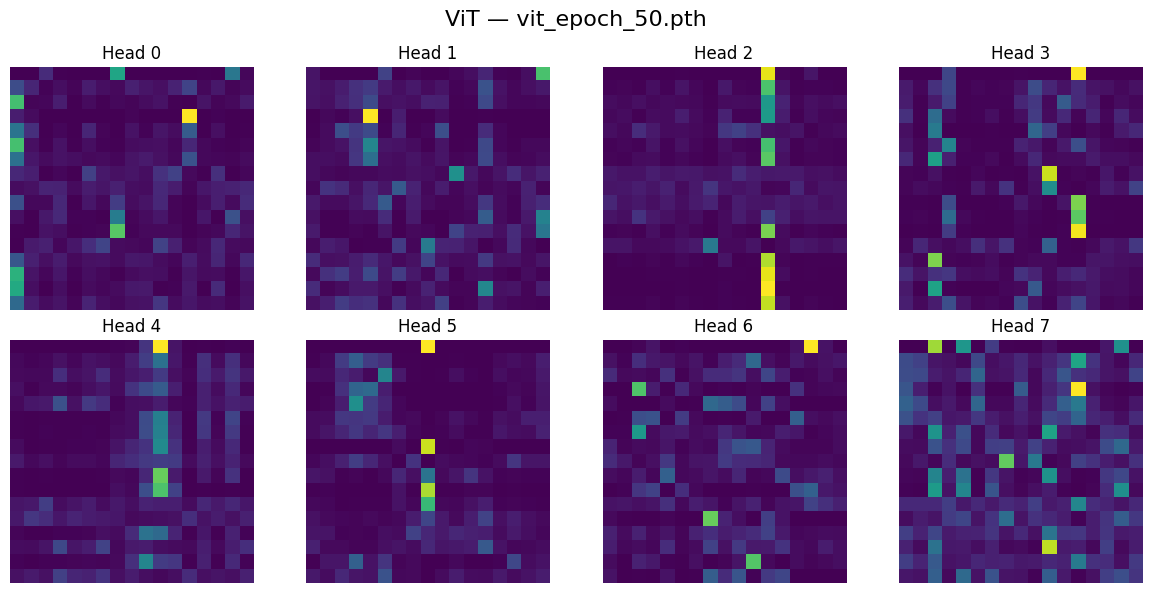

Head 0:
tensor([1.1047, 2.4734, 1.6023, 0.5593, 1.9049, 1.5996, 2.2325, 2.3760, 2.7196,
        2.4057, 1.9922, 1.4668, 2.4575, 2.5599, 1.8151, 1.7752, 2.4182])
 Entropy = 1.9684
Head 1:
tensor([1.3897, 2.5373, 2.4582, 0.7083, 2.0284, 2.0338, 2.2823, 2.1769, 2.4536,
        2.4392, 1.9179, 2.1473, 2.1353, 2.6190, 2.3778, 2.2131, 2.4633])
 Entropy = 2.1401
Head 2:
tensor([0.3580, 1.3758, 1.9813, 1.8649, 2.4744, 1.4372, 1.3391, 2.7833, 2.6971,
        2.7725, 2.6176, 1.1434, 2.2960, 0.8071, 0.4487, 0.2875, 0.6915])
 Entropy = 1.6103
Head 3:
tensor([0.5010, 2.4256, 2.2896, 2.2400, 1.7499, 2.0368, 1.9925, 1.1051, 2.0081,
        1.1515, 1.1022, 0.6985, 2.3446, 1.5023, 2.6046, 1.7418, 2.3361])
 Entropy = 1.7547
Head 4:
tensor([0.7271, 2.2915, 2.6071, 2.3634, 2.5409, 1.8543, 1.8920, 2.0299, 2.5441,
        1.4005, 1.2104, 2.7213, 2.7187, 1.9874, 2.5833, 1.9766, 2.6675])
 Entropy = 2.1245
Head 5:
tensor([0.0038, 1.9867, 1.9797, 1.6491, 1.6052, 2.4559, 2.4806, 0.4276, 2.4134,
        2.1036, 0

In [8]:

from vit import ViT
import torch
import torchvision
import torchvision.transforms as transforms

# создаем модель
model = ViT()

# загружаем чекпоинт
model.load_state_dict(torch.load("vit_epoch_50.pth"))
model.eval()

print(model)



transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

# берем изображение из FashionMNIST
image, label = test_dataset[0]
sample_image = image.unsqueeze(0)

# forward
with torch.no_grad():
    _ = model(sample_image)

# достаем attention
# (batch,heads,tokens,tokens)
attn = model.transformer[0].attn.last_attn
print(attn.shape)


# %%


import matplotlib.pyplot as plt


plt.imshow(image.permute(1, 2, 0))  # если формат (C, H, W)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("ViT — vit_epoch_50.pth", fontsize=16)


for h in range(8):
    A = attn[0, h].cpu()
    ax = axes[h // 4, h % 4]
    im = ax.imshow(A)
    ax.set_title(f"Head {h}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# %%
import torch

num_heads = attn.shape[1]

for h in range(num_heads):
    A = attn[0, h]  # (tokens, tokens)

    # энтропия по строкам
    entropy_per_token = -(A * torch.log(A + 1e-9)).sum(dim=-1)
    print(f"Head {h}:")
    print(entropy_per_token)

    # средняя энтропия головы
    entropy = entropy_per_token.mean().item()

    print(f" Entropy = {entropy:.4f}")




